## 0. Import and Setup

In [1]:
# Setup and imports
import sys
import json
import sqlite3
from pathlib import Path
from pprint import pprint

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /home/feiy/Role-SQL-benchmark


In [2]:
# Load environment and initialize Oracle
from dotenv import load_dotenv
import os

load_dotenv(project_root / '.env')

# Check available API keys
api_keys = {
    'OPENAI_API_KEY': bool(os.getenv('OPENAI_API_KEY')),
    'DEEPSEEK_API_KEY': bool(os.getenv('DEEPSEEK_API_KEY')),
    'DEEPINFRA_API_KEY': bool(os.getenv('DEEPINFRA_API_KEY')),
}
print("Available API keys:")
for k, v in api_keys.items():
    print(f"  {k}: {'✓' if v else '✗'}")

Available API keys:
  OPENAI_API_KEY: ✓
  DEEPSEEK_API_KEY: ✓
  DEEPINFRA_API_KEY: ✓


In [3]:
# Initialize LLM Oracle
from src.llm_oracle import Oracle

# Choose model based on available keys (prefer DeepSeek for cost efficiency)
if os.getenv('DEEPSEEK_API_KEY'):
    MODEL = "deepseek-chat"
    API_KEY = os.getenv('DEEPSEEK_API_KEY')
elif os.getenv('OPENAI_API_KEY'):
    MODEL = "gpt-4o-mini"
    API_KEY = os.getenv('OPENAI_API_KEY')
else:
    raise ValueError("No API key available!")

oracle = Oracle(model=MODEL, apikey=API_KEY)
print(f"Using model: {MODEL}")

Using model: deepseek-chat


/home/feiy/anaconda3/envs/llm4db/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Sample Database Schema

We'll use a BIRD database with interesting column structure for testing.

In [4]:
def get_schema_from_sqlite(db_path: str) -> dict:
    """Extract detailed schema from SQLite database."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get all tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    tables = [row[0] for row in cursor.fetchall()]
    
    schema = {}
    for table in tables:
        cursor.execute(f"PRAGMA table_info(`{table}`)")
        columns = cursor.fetchall()
        
        cursor.execute(f"PRAGMA foreign_key_list(`{table}`)")
        fks = {row[3]: f"{row[2]}.{row[4]}" for row in cursor.fetchall()}
        
        schema[table] = {
            'columns': [
                {
                    'name': col[1],
                    'type': col[2] or 'TEXT',
                    'pk': col[5] == 1,
                    'not_null': col[3] == 1,
                    'fk': fks.get(col[1])
                }
                for col in columns
            ]
        }
    
    conn.close()
    return schema

def format_schema_for_prompt(schema: dict, db_name: str) -> str:
    """Format schema as text for LLM prompt."""
    lines = [f"Database: {db_name}\n"]
    
    for table, info in schema.items():
        lines.append(f"Table: {table}")
        lines.append("Columns:")
        for col in info['columns']:
            constraints = []
            if col['pk']:
                constraints.append("PRIMARY KEY")
            if col['not_null'] and not col['pk']:
                constraints.append("NOT NULL")
            if col['fk']:
                constraints.append(f"FK -> {col['fk']}")
            
            constraint_str = f" [{', '.join(constraints)}]" if constraints else ""
            lines.append(f"  - {col['name']} ({col['type']}){constraint_str}")
        lines.append("")
    
    return "\n".join(lines)

In [5]:
# Load a sample BIRD database - use the latest 2025 version
bird_db_dir = project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev_databases'

# List available databases
available_dbs = [d.name for d in bird_db_dir.iterdir() if d.is_dir()]
print(f"Available BIRD databases ({len(available_dbs)}):")
for db in sorted(available_dbs)[:10]:
    print(f"  - {db}")
print("  ...")

Available BIRD databases (11):
  - california_schools
  - card_games
  - codebase_community
  - debit_card_specializing
  - european_football_2
  - financial
  - formula_1
  - student_club
  - superhero
  - thrombosis_prediction
  ...


In [6]:
# Select a database with moderate complexity
# 'california_schools' has tables with sensitive-looking columns
TEST_DB = "california_schools"
db_path = bird_db_dir / TEST_DB / f"{TEST_DB}.sqlite"

print(f"Loading schema from: {db_path}")
schema = get_schema_from_sqlite(str(db_path))

print(f"\nTables: {list(schema.keys())}")
for table, info in schema.items():
    print(f"\n{table}: {len(info['columns'])} columns")
    for col in info['columns'][:5]:
        print(f"  - {col['name']} ({col['type']})")
    if len(info['columns']) > 5:
        print(f"  ... and {len(info['columns']) - 5} more")

Loading schema from: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev_databases/california_schools/california_schools.sqlite

Tables: ['frpm', 'satscores', 'schools']

frpm: 29 columns
  - CDSCode (TEXT)
  - Academic Year (TEXT)
  - County Code (TEXT)
  - District Code (INTEGER)
  - School Code (TEXT)
  ... and 24 more

satscores: 11 columns
  - cds (TEXT)
  - rtype (TEXT)
  - sname (TEXT)
  - dname (TEXT)
  - cname (TEXT)
  ... and 6 more

schools: 49 columns
  - CDSCode (TEXT)
  - NCESDist (TEXT)
  - NCESSchool (TEXT)
  - StatusType (TEXT)
  - County (TEXT)
  ... and 44 more


In [7]:
# Format schema for prompt
schema_text = format_schema_for_prompt(schema, TEST_DB)
print(schema_text[:2000])
print(f"\n... (total {len(schema_text)} characters)")

Database: california_schools

Table: frpm
Columns:
  - CDSCode (TEXT) [PRIMARY KEY, FK -> schools.CDSCode]
  - Academic Year (TEXT)
  - County Code (TEXT)
  - District Code (INTEGER)
  - School Code (TEXT)
  - County Name (TEXT)
  - District Name (TEXT)
  - School Name (TEXT)
  - District Type (TEXT)
  - School Type (TEXT)
  - Educational Option Type (TEXT)
  - NSLP Provision Status (TEXT)
  - Charter School (Y/N) (INTEGER)
  - Charter School Number (TEXT)
  - Charter Funding Type (TEXT)
  - IRC (INTEGER)
  - Low Grade (TEXT)
  - High Grade (TEXT)
  - Enrollment (K-12) (REAL)
  - Free Meal Count (K-12) (REAL)
  - Percent (%) Eligible Free (K-12) (REAL)
  - FRPM Count (K-12) (REAL)
  - Percent (%) Eligible FRPM (K-12) (REAL)
  - Enrollment (Ages 5-17) (REAL)
  - Free Meal Count (Ages 5-17) (REAL)
  - Percent (%) Eligible Free (Ages 5-17) (REAL)
  - FRPM Count (Ages 5-17) (REAL)
  - Percent (%) Eligible FRPM (Ages 5-17) (REAL)
  - 2013-14 CALPADS Fall 1 Certification Status (INTEGER)

Ta

## 2. Load Prompts from External Modules

Prompts are now defined in `configs/column_level_prompts.py`.
- **JSON format** is used (more structured, requires max_tokens=4000)
- Parser auto-detects format and handles both JSON and Plain Text

In [8]:
# Reload modules to get latest changes
import importlib
import configs.column_level_prompts
import src.role_parser.column_level_parser
importlib.reload(configs.column_level_prompts)
importlib.reload(src.role_parser.column_level_parser)

# Import prompts and parser from external modules
from configs.column_level_prompts import (
    COLUMN_LEVEL_SYSTEM_PROMPT, 
    COLUMN_LEVEL_USER_PROMPT_TEMPLATE,
    DEFAULT_MAX_TOKENS
)
from src.role_parser import parse_column_level_roles, validate_roles_against_schema

print("✓ Loaded from external modules:")
print(f"  - COLUMN_LEVEL_SYSTEM_PROMPT ({len(COLUMN_LEVEL_SYSTEM_PROMPT)} chars)")
print(f"  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE")
print(f"  - DEFAULT_MAX_TOKENS = {DEFAULT_MAX_TOKENS}")
print(f"  - parse_column_level_roles (auto-detects JSON/Text)")
print(f"  - validate_roles_against_schema")

print("\n--- System Prompt Preview ---")
print(COLUMN_LEVEL_SYSTEM_PROMPT[:500])
print("...")

✓ Loaded from external modules:
  - COLUMN_LEVEL_SYSTEM_PROMPT (2734 chars)
  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE
  - DEFAULT_MAX_TOKENS = 4000
  - parse_column_level_roles (auto-detects JSON/Text)
  - validate_roles_against_schema

--- System Prompt Preview ---
You are a database security expert specializing in fine-grained Role-Based Access Control (RBAC).
Your job is to read a relational database schema and propose a COHERENT set of roles with COLUMN-LEVEL permissions.

Key goals:
- Minimize role count while covering real-world workflows (decide number of roles according to real world scenario).
- Each role must be clearly related to others (same scenario, complementary duties).
- Enforce least-privilege at the COLUMN level (specify which columns eac
...


## [Archived] Single-Sample Experiments

以下代码块包含单样本测试代码，用于调试 prompt 和 parser。
**已注释，正式运行请跳过此节，直接执行第8节批量处理。**

In [9]:
# ============================================================
# [ARCHIVED] 单样本实验代码 - 已注释，跳过此cell
# ============================================================
# 以下代码用于单个数据库 (california_schools) 的测试和调试
# 正式运行请直接跳到第8节批量处理

'''
# --- 3. Generate Column-Level Roles (Single DB) ---
print("Generating column-level roles...")
user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=schema_text)
response = oracle.query(
    prompt_sys=COLUMN_LEVEL_SYSTEM_PROMPT,
    prompt_user=user_prompt,
    temp=0.3, top_p=0.9,
    max_completion_tokens=DEFAULT_MAX_TOKENS
)
llm_response = response['answer']
print(f"Response length: {len(llm_response)} chars")

# --- 4. Parse and Validate ---
from src.role_parser.column_level_parser import parse_column_level_roles
parsed_roles = parse_column_level_roles(llm_response)
print(f"Parsed {len(parsed_roles)} roles")

validation = validate_roles_against_schema(parsed_roles, str(db_path))
print(f"Valid: {validation['valid_roles']}/{validation['total_roles']}")

# --- 5. Show Results ---
for role in parsed_roles:
    print(f"  - {role['role']}: {len(role.get('columns', {}))} tables")

# --- 6. Compare with Table-Level ---
from configs.prompts import SYSTEM_PROMPT as TABLE_LEVEL_PROMPT, USER_PROMPT_TEMPLATE
table_level_response = oracle.query(
    prompt_sys=TABLE_LEVEL_PROMPT,
    prompt_user=USER_PROMPT_TEMPLATE.format(schema_content=schema_text),
    temp=0.3, top_p=0.9
)
print("Table-Level Response:", table_level_response['answer'][:500])

# --- 7. Save Single DB Result ---
def convert_to_assignment_format(parsed_roles, db_name):
    return {"assignments": {db_name: [
        {"role": r["role"], "description": r.get("description", ""), "policy": r.get("columns", {})}
        for r in parsed_roles
    ]}}

column_level_assignments = convert_to_assignment_format(parsed_roles, TEST_DB)
output_file = project_root / 'outputs' / 'column_level_role_assignments.json'
with open(output_file, 'w') as f:
    json.dump(column_level_assignments, f, indent=2, ensure_ascii=False)
print(f"Saved to: {output_file}")
'''

print("⏭️ 此cell已注释，跳过单样本实验，请直接运行第8节批量处理")

⏭️ 此cell已注释，跳过单样本实验，请直接运行第8节批量处理


## 3. Batch Process All BIRD Databases

Generate column-level role assignments for all BIRD databases with parallel processing.

In [10]:
# Batch processing configuration
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Configuration
WORKERS = 40
SAMPLES = 100  # 0 for all databases
MAX_TOKENS = DEFAULT_MAX_TOKENS

# Get all BIRD databases
all_dbs = [d.name for d in bird_db_dir.iterdir() if d.is_dir()]
if SAMPLES > 0:
    all_dbs = all_dbs[:SAMPLES]

print(f"Configuration:")
print(f"  Workers: {WORKERS}")
print(f"  Databases: {len(all_dbs)}")
print(f"  Max tokens: {MAX_TOKENS}")
print(f"  Model: {MODEL}")
print(f"\nDatabases to process:")
for db in all_dbs:
    print(f"  - {db}")

Configuration:
  Workers: 40
  Databases: 11
  Max tokens: 4000
  Model: deepseek-chat

Databases to process:
  - superhero
  - thrombosis_prediction
  - student_club
  - toxicology
  - california_schools
  - debit_card_specializing
  - card_games
  - codebase_community
  - formula_1
  - european_football_2
  - financial


In [11]:
# Helper functions for batch processing

def process_single_database(db_name: str) -> dict:
    """Process a single database and return role assignments."""
    db_path = bird_db_dir / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": f"Database not found"}
    
    try:
        # Extract schema
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        # Generate roles via LLM
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=COLUMN_LEVEL_SYSTEM_PROMPT,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        
        # Parse response
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {
                "database": db_name,
                "status": "parse_error",
                "error": "Failed to parse LLM response",
                "raw_response": llm_response[:300]
            }
        
        # Validate against schema
        validation = validate_roles_against_schema(roles, str(db_path))
        
        # Convert to target format
        assignments = []
        for role in roles:
            assignments.append({
                "role": role["role"],
                "description": role.get("description", ""),
                "policy": role.get("columns", {})
            })
        
        return {
            "database": db_name,
            "status": "success",
            "roles_count": len(assignments),
            "valid_roles": validation['valid_roles'],
            "all_valid": validation['all_valid'],
            "assignments": assignments,
            "usage": usage
        }
        
    except Exception as e:
        return {
            "database": db_name,
            "status": "error",
            "error": str(e)
        }

print("✓ Helper functions defined")

✓ Helper functions defined


In [12]:
# Execute batch processing with parallel workers
print(f"Starting batch processing with {WORKERS} workers...")
print("=" * 60)

results = {
    "metadata": {
        "model": MODEL,
        "max_tokens": MAX_TOKENS,
        "total_databases": len(all_dbs)
    },
    "assignments": {},
    "errors": []
}

success_count = 0
error_count = 0
total_tokens = {"prompt": 0, "completion": 0}

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {executor.submit(process_single_database, db): db for db in all_dbs}
    
    for i, future in enumerate(as_completed(futures), 1):
        db_name = futures[future]
        try:
            result = future.result()
            
            if result["status"] == "success":
                results["assignments"][result["database"]] = result["assignments"]
                success_count += 1
                
                usage = result.get("usage", {})
                total_tokens["prompt"] += usage.get("prompt_tokens", 0)
                total_tokens["completion"] += usage.get("completion_tokens", 0)
                
                print(f"[{i}/{len(all_dbs)}] ✓ {db_name}: {result['roles_count']} roles ({result['valid_roles']} valid)")
            else:
                results["errors"].append(result)
                error_count += 1
                print(f"[{i}/{len(all_dbs)}] ✗ {db_name}: {result.get('error', result['status'])}")
                
        except Exception as e:
            error_count += 1
            results["errors"].append({"database": db_name, "error": str(e)})
            print(f"[{i}/{len(all_dbs)}] ✗ {db_name}: {e}")

results["metadata"]["success_count"] = success_count
results["metadata"]["error_count"] = error_count
results["metadata"]["total_tokens"] = total_tokens

print("=" * 60)
print(f"Completed: {success_count}/{len(all_dbs)} success, {error_count} errors")
print(f"Total tokens: {total_tokens['prompt'] + total_tokens['completion']:,}")

Starting batch processing with 40 workers...
[1/11] ✓ toxicology: 4 roles (4 valid)
[2/11] ✓ debit_card_specializing: 4 roles (4 valid)
[3/11] ✓ thrombosis_prediction: 4 roles (4 valid)
[4/11] ✓ student_club: 5 roles (5 valid)
[5/11] ✓ superhero: 5 roles (5 valid)
[6/11] ✓ financial: 5 roles (5 valid)
[7/11] ✓ card_games: 5 roles (5 valid)
[8/11] ✓ codebase_community: 4 roles (4 valid)
[9/11] ✓ california_schools: 5 roles (5 valid)
[10/11] ✓ formula_1: 5 roles (5 valid)
[11/11] ✓ european_football_2: 5 roles (5 valid)
Completed: 11/11 success, 0 errors
Total tokens: 25,679


In [13]:
# Save batch results to file
output_file = project_root / 'outputs' / 'column_level_role_assignments_bird.json'

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {output_file}")
print(f"\nFile structure:")
print(f"  - metadata: model, tokens, counts")
print(f"  - assignments: {len(results['assignments'])} databases")
print(f"  - errors: {len(results['errors'])} entries")

# Show sample
if results['assignments']:
    sample_db = list(results['assignments'].keys())[0]
    print(f"\nSample ({sample_db}):")
    print(json.dumps(results['assignments'][sample_db][:1], indent=2, ensure_ascii=False)[:500])

✓ Results saved to: /home/feiy/Role-SQL-benchmark/outputs/column_level_role_assignments_bird.json

File structure:
  - metadata: model, tokens, counts
  - assignments: 11 databases
  - errors: 0 entries

Sample (toxicology):
[
  {
    "role": "MolecularResearcher",
    "description": "Analyzes molecular structures and their components for research purposes",
    "policy": {
      "molecule": [
        "molecule_id",
        "label"
      ],
      "atom": [
        "atom_id",
        "molecule_id",
        "element"
      ],
      "bond": [
        "bond_id",
        "molecule_id",
        "bond_type"
      ],
      "connected": [
        "atom_id",
        "atom_id2",
        "bond_id"
      ]
    }
  }
]


## 4. Generate Column-Level RBAC Dataset

Based on the generated role policies, combined with BIRD dataset queries, generate the final RBAC training/evaluation dataset.

Dataset format (consistent with table-level):
- `db_id`: Database name
- `instruction`: Full instruction with schema + evidence + role policy
- `role`: Role name
- `policy`: Column-level permission policy {table: [columns]}
- `input`: User question
- `output`: SQL or denial message
- `difficulty`: Query difficulty level
- `metadata`: Contains gold_sql, permission, query_columns, missing_columns, etc.

In [14]:
# 4.1 Import generator and test dependencies
from src.processors.column_level_rbac_generator import ColumnLevelRBACGenerator, format_policy_text
from src.processors.column_extractor import extract_query_columns
from src.processors.column_permission_checker import check_column_permission

# Configure paths - use 2025 version (dev_20251106) for latest BIRD data
ROLE_ASSIGNMENTS_PATH = project_root / 'outputs' / 'column_level_role_assignments_bird.json'
BIRD_DATA_PATH = project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev.json'
BIRD_DB_ROOT = project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev_databases'

print("=== Dataset Generation Config ===")
print(f"Role assignments: {ROLE_ASSIGNMENTS_PATH}")
print(f"BIRD data file: {BIRD_DATA_PATH}")
print(f"BIRD database dir: {BIRD_DB_ROOT}")

# Verify file existence
assert ROLE_ASSIGNMENTS_PATH.exists(), f"Role assignments file not found: {ROLE_ASSIGNMENTS_PATH}"
assert BIRD_DATA_PATH.exists(), f"BIRD data file not found: {BIRD_DATA_PATH}"
assert BIRD_DB_ROOT.exists(), f"BIRD database dir not found: {BIRD_DB_ROOT}"
print("\n✓ All file paths are valid")

=== Dataset Generation Config ===
Role assignments: /home/feiy/Role-SQL-benchmark/outputs/column_level_role_assignments_bird.json
BIRD data file: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev.json
BIRD database dir: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev_databases

✓ All file paths are valid


In [ ]:
# [ARCHIVED] 4.2 Test SQL column extraction and permission checking
# 已验证工作正常，archive 以简化 notebook

'''
test_sql = """
SELECT singer.name, singer.age, song.title
FROM singer
JOIN song ON singer.id = song.singer_id
WHERE singer.country = 'USA'
"""

print("=== SQL Column Extraction Test ===")
info = extract_query_columns(test_sql)
print(f"Tables: {info.tables}")
print(f"Columns: {info.columns}")
print(f"Has *: {info.has_star}")

# Test permission checking
policy_allow = {
    'singer': ['name', 'age', 'country', 'id'],
    'song': ['title', 'singer_id']
}
policy_deny = {
    'singer': ['name'],  # Missing 'age', 'country', 'id'
    'song': ['title']    # Missing 'singer_id'
}

print("\n=== Permission Check Test (Allow) ===")
result1 = check_column_permission(test_sql, policy_allow)
print(f"Allowed: {result1.allowed}")
print(f"Reason: {result1.reason}")

print("\n=== Permission Check Test (Deny) ===")
result2 = check_column_permission(test_sql, policy_deny)
print(f"Allowed: {result2.allowed}")
print(f"Reason: {result2.reason}")
print(f"Missing: {result2.missing_columns}")
'''

print("⏭️ [ARCHIVED] Column extraction/permission tests - 已验证正常")

=== SQL Column Extraction Test ===
Tables: {'song', 'singer'}
Columns: {'song': {'singer_id', 'title'}, 'singer': {'id', 'name', 'country', 'age'}}
Has *: False

=== Permission Check Test (Allow) ===
Allowed: True
Reason: All required columns are permitted

=== Permission Check Test (Deny) ===
Allowed: False
Reason: Missing column permissions: song: singer_id; singer: age, country, id
Missing: {'song': {'singer_id'}, 'singer': {'id', 'country', 'age'}}


In [16]:
# 4.3 Initialize generator
generator = ColumnLevelRBACGenerator(
    role_assignments_path=str(ROLE_ASSIGNMENTS_PATH),
    bird_data_path=str(BIRD_DATA_PATH),
    bird_db_root=str(BIRD_DB_ROOT),
    project_root=str(project_root),
    seed=42
)

print("=== Generator Initialized ===")
print(f"Total BIRD queries: {len(generator.bird_data)}")
print(f"Databases with role assignments: {len(generator.role_assignments.get('assignments', {}))}")
print(f"Databases with queries: {len(generator.queries_by_db)}")

# Show query counts per database
print("\nQueries per database:")
for db_id, queries in sorted(generator.queries_by_db.items()):
    print(f"  {db_id}: {len(queries)}")

=== Generator Initialized ===
Total BIRD queries: 1534
Databases with role assignments: 11
Databases with queries: 11

Queries per database:
  california_schools: 89
  card_games: 191
  codebase_community: 186
  debit_card_specializing: 64
  european_football_2: 129
  financial: 106
  formula_1: 174
  student_club: 158
  superhero: 129
  thrombosis_prediction: 163
  toxicology: 145


In [ ]:
# [ARCHIVED] 4.4 Generate sample dataset (for format validation)
# Sample 数据集已用于调试，正式生成使用 4.5

'''
print("=== Generating Sample Dataset ===")
sample_stats = generator.generate_and_save(
    output_path=str(project_root / 'outputs' / 'column_level_rbac_dataset_bird_sample.json'),
    roles_per_db=1,      # Use only 1 role per database
    queries_per_role=3   # Use only 3 queries per role
)

print("\\nStatistics:")
for k, v in sample_stats.items():
    if k != 'by_database':
        print(f"  {k}: {v}")
'''

print("⏭️ [ARCHIVED] Sample dataset generation - 正式生成使用 4.5")

=== Generating Sample Dataset ===
Generating column-level RBAC dataset...
  Roles per DB: 1
  Queries per role: 3
Current ratio (allowed): 60.61%
  Allowed: 20, Denied: 13

Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_sample.json
Metadata saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_sample_metadata.json
  Total entries: 33
  Allowed: 20 (60.6%)
  Denied: 13 (39.4%)

Statistics:
  total_entries: 33
  allowed: 20
  denied: 13
  allowed_ratio: 0.6060606060606061


In [ ]:
# [ARCHIVED] 4.5-4.6 Validate generated data format & Show instruction example
# 已验证数据格式正确，archive 以简化 notebook

'''
sample_file = project_root / 'outputs' / 'column_level_rbac_dataset_bird_sample.json'
with open(sample_file, 'r') as f:
    sample_data = json.load(f)

print("=== Data Format Validation ===")
print(f"Total entries: {len(sample_data)}")

allowed_entry = next((e for e in sample_data if e['metadata']['permission'] == 'allowed'), None)
denied_entry = next((e for e in sample_data if e['metadata']['permission'] == 'denied'), None)

if allowed_entry:
    print("\\n--- Allowed Entry Example ---")
    print(f"db_id: {allowed_entry['db_id']}")
    print(f"role: {allowed_entry['role']}")
    print(f"policy: {json.dumps(allowed_entry['policy'])[:100]}...")
    print(f"input: {allowed_entry['input'][:80]}...")
    print(f"output: {allowed_entry['output'][:80]}...")

if denied_entry:
    print("\\n--- Denied Entry Example ---")
    print(f"db_id: {denied_entry['db_id']}")
    print(f"role: {denied_entry['role']}")
    print(f"output: {denied_entry['output']}")
    print(f"missing_columns: {denied_entry['metadata']['missing_columns']}")

# Show full instruction
print("\\n=== Full Instruction Example ===")
if allowed_entry:
    print(allowed_entry['instruction'][:2500])
'''

print("⏭️ [ARCHIVED] Data format validation - 已验证正常")

=== Data Format Validation ===
Total entries: 33

--- Allowed Entry Example ---
db_id: toxicology
role: MolecularResearcher
policy: {"molecule": ["molecule_id", "label"], "atom": ["atom_id", "molecule_id", "element"], "bond": ["bond...
input: What are the atom IDs of the bond TR000_2_5?...
output: SELECT T.atom_id FROM connected AS T WHERE T.bond_id = 'TR000_2_5'...
difficulty: simple
instruction length: 1887 chars

--- Denied Entry Example ---
db_id: thrombosis_prediction
role: ClinicalResearcher
input: How old was the patient who had the highest hemoglobin count on the date of labo...
output: Sorry, I cannot answer.
missing_columns: {'patient': ['Diagnosis']}


In [ ]:
# 4.5 Generate Full Column-Level RBAC Dataset
from datetime import datetime

# Reload the modules to ensure we use the latest CTE fix
import importlib
import src.processors.column_extractor
import src.processors.column_permission_checker
import src.processors.column_level_rbac_generator

importlib.reload(src.processors.column_extractor)
importlib.reload(src.processors.column_permission_checker)
importlib.reload(src.processors.column_level_rbac_generator)

# Re-import with fresh code
from src.processors.column_level_rbac_generator import ColumnLevelRBACGenerator

# Re-create generator with fresh modules
generator = ColumnLevelRBACGenerator(
    bird_db_root=str(BIRD_DB_ROOT),
    role_assignments_path=str(ROLE_ASSIGNMENTS_PATH),
    bird_data_path=str(BIRD_DATA_PATH)
)

# Output with date suffix
today = datetime.now().strftime('%Y%m%d')
output_path = project_root / 'outputs' / f'column_level_rbac_dataset_bird_{today}.json'

print("=== Generating Full Column-Level RBAC Dataset ===")
print(f"Output: {output_path}")

full_stats = generator.generate_and_save(
    output_path=str(output_path),
    roles_per_db=None,    # Use all roles (number varies per db based on LLM generation)
    queries_per_role=None # Use all queries
)

print("\nFull dataset statistics:")
for k, v in full_stats.items():
    if k == 'by_database':
        print(f"\nPer-database distribution:")
        for db_id, counts in v.items():
            print(f"  {db_id}: allowed={counts['allowed']}, denied={counts['denied']}")
    else:
        print(f"  {k}: {v}")

=== Generating Full Column-Level RBAC Dataset ===
Output: /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251224.json
Note: Using updated column_extractor with CTE fix
Generating column-level RBAC dataset...
  Roles per DB: None
  Queries per role: all
Current ratio (allowed): 61.18%
  Allowed: 4351, Denied: 2761

Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251224.json
Metadata saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251224_metadata.json
  Total entries: 7112
  Allowed: 4351 (61.2%)
  Denied: 2761 (38.8%)

Full dataset statistics:
  total_entries: 7112
  allowed: 4351
  denied: 2761
  allowed_ratio: 0.6117829021372329

Per-database distribution:
  toxicology: allowed=580, denied=0
  debit_card_specializing: allowed=223, denied=33
  thrombosis_prediction: allowed=432, denied=220
  student_club: allowed=396, denied=394
  superhero: allowed=328, denied=317
  financial: allowed=212, d

In [ ]:
# [ARCHIVED] 4.6 Compare with Table-Level format
# 格式对比已完成，archive 以简化 notebook

'''
print("=== Comparison with Table-Level Data Format ===")

table_level_file = project_root / 'data' / 'selected' / 'bird' / 'bird_dev_with_role_rbac.json'
if table_level_file.exists():
    with open(table_level_file, 'r') as f:
        table_level_data = json.load(f)
    
    print("\\n--- Table-Level Entry Fields ---")
    print(sorted(table_level_data[0].keys()))
    
    print("\\n--- Column-Level Entry Fields ---")  
    print(sorted(sample_data[0].keys()))
    
    tl_keys = set(table_level_data[0].keys())
    cl_keys = set(sample_data[0].keys())
    
    print(f"\\nCommon fields: {tl_keys & cl_keys}")
    print(f"Table-Level only: {tl_keys - cl_keys}")
    print(f"Column-Level only: {cl_keys - tl_keys}")
'''

print("⏭️ [ARCHIVED] Table-level comparison - 格式已验证兼容")

=== Comparison with Table-Level Data Format ===

--- Table-Level Entry Fields ---
['db_id', 'difficulty', 'input', 'instruction', 'metadata', 'output', 'role', 'tables']

--- Column-Level Entry Fields ---
['db_id', 'difficulty', 'input', 'instruction', 'metadata', 'output', 'policy', 'role']

Common fields: {'output', 'role', 'metadata', 'difficulty', 'db_id', 'input', 'instruction'}
Table-Level only: {'tables'}
Column-Level only: {'policy'}


## 5. Role Generation Quality Assessment

Automated quality checks for generated role files and RBAC datasets.

### Quality Metrics

| Metric | Healthy Range | Issue Description |
|--------|---------------|-------------------|
| **Deny Rate** | 5% - 90% | <5% too permissive, >90% too restrictive |
| **All-Allow Queries** | <50% | High value indicates poor role differentiation |
| **Role-Schema Similarity** | >0.6 | <0.6 indicates poor semantic alignment |
| **Policy Overlap** | <70% | >70% indicates redundant roles |
| **Coverage Diversity** | std >0.1 | Low std indicates roles have similar permissions |

### Evaluation Pipeline
1. **Deny Rate Analysis**: Check permission distribution balance
2. **Semantic Quality**: Embedding-based role-schema alignment
3. **Policy Overlap**: Jaccard similarity to detect redundant roles

In [123]:
# 5.1 Setup Quality Evaluator (force reload all modules)
import importlib
import sys
from pathlib import Path
import glob

# Force reload the entire module tree
if 'src.role_evaluator.quality_metrics' in sys.modules:
    del sys.modules['src.role_evaluator.quality_metrics']
if 'src.role_evaluator.quality_visualizer' in sys.modules:
    del sys.modules['src.role_evaluator.quality_visualizer']
if 'src.role_evaluator' in sys.modules:
    del sys.modules['src.role_evaluator']

from src.role_evaluator import RoleQualityEvaluator, RoleQualityVisualizer, print_quality_report

# Configure paths
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Find most recent dataset and role assignments files
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_bird_*.json')))
ROLE_ASSIGNMENTS_PATH = role_files[-1] if role_files else str(project_root / 'outputs' / 'column_level_role_assignments_bird.json')

dataset_files = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'column_level_rbac_dataset_bird_*.json')) 
                        if 'metadata' not in f])
if not dataset_files:
    raise FileNotFoundError("No RBAC dataset found in outputs/")
DATASET_PATH = dataset_files[-1]

SCHEMA_DIR = str(project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev_databases')

print(f"Role Assignments: {Path(ROLE_ASSIGNMENTS_PATH).name}")
print(f"Dataset: {Path(DATASET_PATH).name}")
print(f"Schema Dir: {SCHEMA_DIR}")

# Initialize evaluator
evaluator = RoleQualityEvaluator(
    role_assignments_path=ROLE_ASSIGNMENTS_PATH,
    dataset_path=DATASET_PATH,
    schema_dir=SCHEMA_DIR
)
print("\nQuality evaluator initialized")

Role Assignments: column_level_role_assignments_bird_20251224_v2.json
Dataset: column_level_rbac_dataset_bird_20251224_v2.json
Schema Dir: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev_databases

Quality evaluator initialized


In [124]:
# 5.2 Run Quality Evaluations and Display as DataFrame
import pandas as pd
import importlib

# Force reload modules to use latest code (removes cached emoji)
import src.role_evaluator.quality_metrics
import src.role_evaluator.quality_visualizer
importlib.reload(src.role_evaluator.quality_metrics)
importlib.reload(src.role_evaluator.quality_visualizer)

from src.role_evaluator.quality_metrics import print_quality_report

# Run evaluation
report = evaluator.evaluate_all()

# Convert to DataFrames for cleaner display
print(f"Overall: {report.total_databases} databases, {report.total_roles} roles, {report.total_entries} entries")
print(f"Pass Rate: {report.pass_rate:.1%} ({report.total_databases - len(report.databases_with_issues)}/{report.total_databases} pass)\n")

# Deny Rate DataFrame
if report.deny_rate_metrics:
    deny_df = pd.DataFrame([
        {
            "Database": db_id,
            "Deny%": f"{m.deny_rate:.1f}%",
            "AllAllow%": f"{m.all_allow_pct:.1f}%",
            "AllDeny": m.all_deny_queries,
            "Roles": len(m.roles),
            "Status": "WARN" if m.issues else "OK"
        }
        for db_id, m in sorted(report.deny_rate_metrics.items())
    ])
    print("=== Deny Rate Analysis ===")
    display(deny_df)

# Semantic Quality DataFrame  
if report.semantic_metrics:
    sem_df = pd.DataFrame([
        {
            "Database": db_id,
            "Similarity": f"{m.avg_similarity:.4f}",
            "Coverage": f"{m.avg_coverage:.1%}",
            "Diversity": f"{m.coverage_std:.4f}",
            "Status": "WARN" if m.issues else "OK"
        }
        for db_id, m in sorted(report.semantic_metrics.items())
    ])
    print("\n=== Semantic Quality (Similarity: role-schema alignment, Coverage: column access, Diversity: coverage std) ===")
    display(sem_df)

# Policy Overlap DataFrame
if report.overlap_metrics:
    ovl_df = pd.DataFrame([
        {
            "Database": db_id,
            "AvgOverlap": f"{m.avg_overlap:.1%}",
            "MaxOverlap": f"{m.max_overlap:.1%}",
            "Status": "WARN" if m.issues else "OK"
        }
        for db_id, m in sorted(report.overlap_metrics.items())
    ])
    print("\n=== Policy Overlap Analysis ===")
    display(ovl_df)

/home/feiy/Role-SQL-benchmark/plot/embedding_utils.py:108: RuntimeWarning: Environment requested OpenAI backend but model 'BAAI/bge-small-en-v1.5' does not look like an OpenAI embedding model. Falling back to 'fastembed'.
  warnings.warn(


[embedding_utils] Using FastEmbed (BAAI/bge-small-en-v1.5) for 11 texts
[embedding_utils] Using FastEmbed (BAAI/bge-small-en-v1.5) for 43 texts
Overall: 11 databases, 51 roles, 7112 entries
Pass Rate: 54.5% (6/11 pass)

=== Deny Rate Analysis ===


,Database,Deny%,AllAllow%,AllDeny,Roles,Status
0,california_schools,61.1%,2.2%,0,5,OK
1,card_games,46.9%,2.1%,0,5,OK
2,codebase_community,10.1%,60.2%,0,4,OK
3,debit_card_specializing,12.9%,62.5%,0,4,OK
4,european_football_2,56.9%,1.6%,0,5,OK
5,financial,60.0%,2.8%,0,5,OK
6,formula_1,36.4%,12.1%,0,5,OK
7,student_club,49.9%,1.3%,0,5,OK
8,superhero,49.1%,0.0%,0,5,OK
9,thrombosis_prediction,33.7%,2.5%,0,4,OK



=== Semantic Quality (Similarity: role-schema alignment, Coverage: column access, Diversity: coverage std) ===


,Database,Similarity,Coverage,Diversity,Status
0,california_schools,0.8243,55.3%,0.1198,OK
1,card_games,0.8370,50.0%,0.2965,OK
2,codebase_community,0.8233,92.0%,0.0937,WARN
3,debit_card_specializing,0.8023,88.9%,0.0978,WARN
4,european_football_2,0.8256,31.3%,0.0984,WARN
5,financial,0.7957,63.2%,0.0452,WARN
6,formula_1,0.8110,65.7%,0.1286,OK
7,student_club,0.8224,50.5%,0.1701,OK
8,superhero,0.8226,61.3%,0.1895,OK
9,thrombosis_prediction,0.7983,69.3%,0.3798,OK



=== Policy Overlap Analysis ===


,Database,AvgOverlap,MaxOverlap,Status
0,california_schools,50.8%,75.6%,WARN
1,card_games,11.9%,23.8%,OK
2,codebase_community,51.8%,76.1%,WARN
3,debit_card_specializing,83.6%,90.5%,WARN
4,european_football_2,14.4%,23.8%,OK
5,financial,27.8%,42.6%,OK
6,formula_1,50.1%,60.0%,OK
7,student_club,30.2%,45.0%,OK
8,superhero,33.0%,52.6%,OK
9,thrombosis_prediction,18.1%,38.5%,OK


In [129]:
# 5.3 Quality Dashboard Visualization
import matplotlib.pyplot as plt
from src.role_evaluator.quality_visualizer import RoleQualityVisualizer

visualizer = RoleQualityVisualizer(evaluator=evaluator, report=report)
fig = visualizer.plot_quality_dashboard()
plt.show()

/home/feiy/Role-SQL-benchmark/src/role_evaluator/quality_visualizer.py:365: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(db_names, rotation=45, ha='right')


Total roles: 51, SystemManager: 11


/tmp/ipykernel_1609080/3186404360.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.95,0.95])


Saved: /home/feiy/Role-SQL-benchmark/plot/column_level_rbac_semantic.png


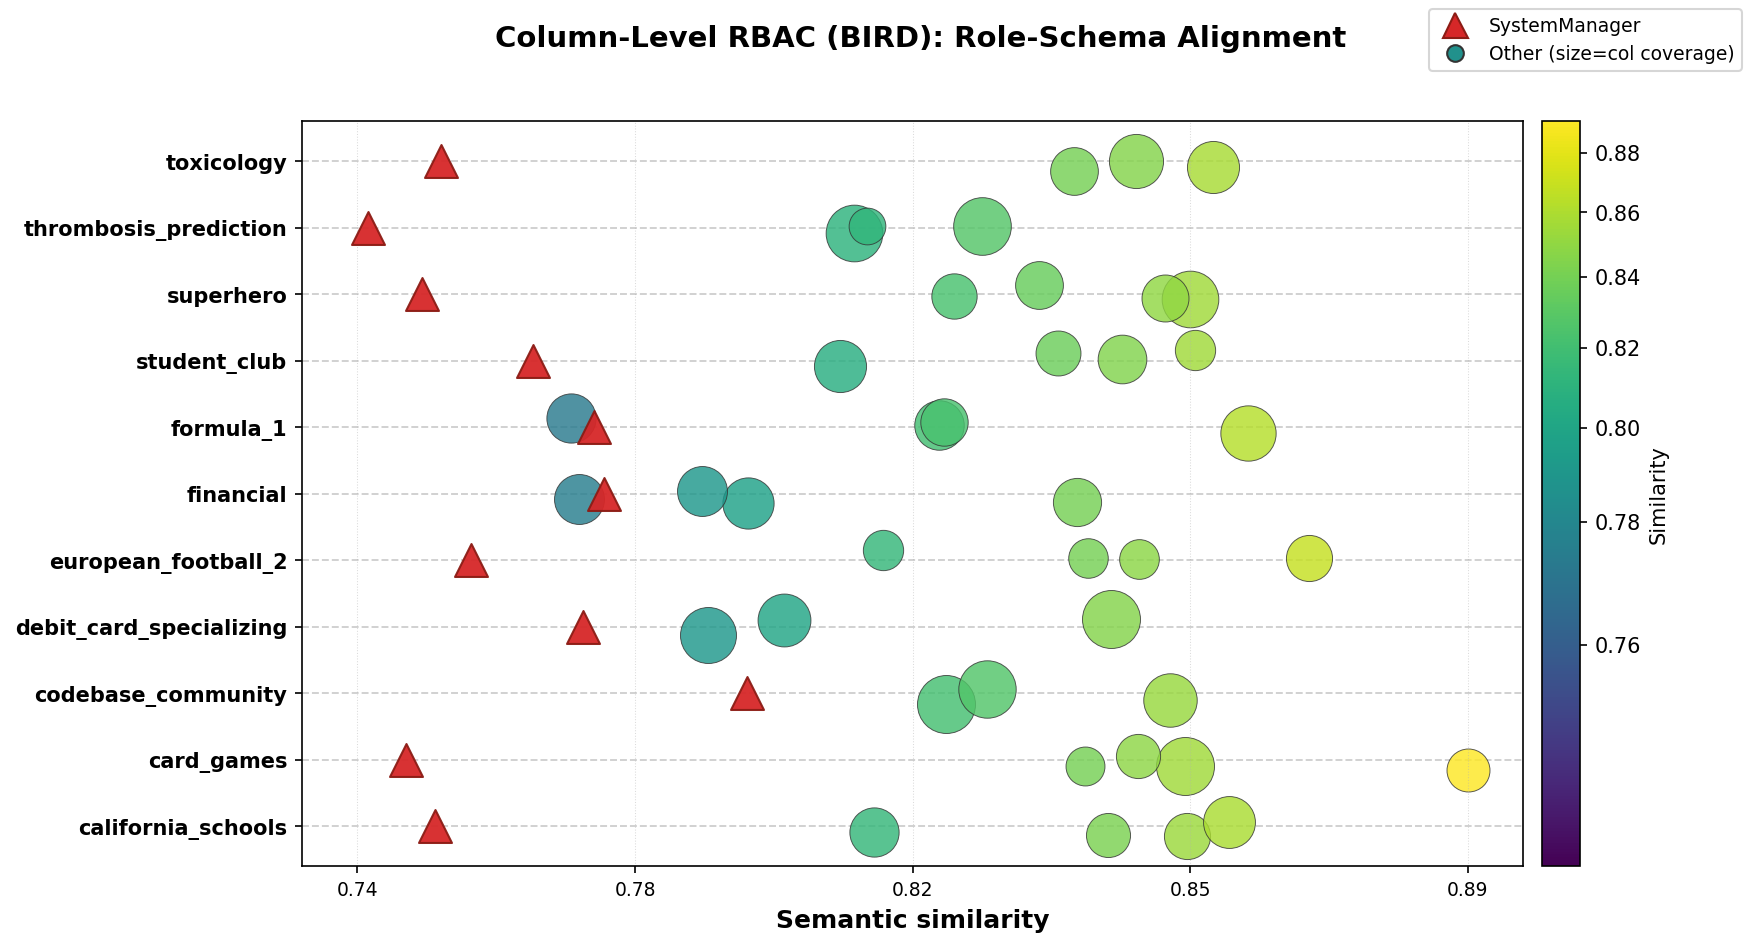

In [130]:
# 5.4 Semantic Alignment Visualization (Column-Level RBAC)
# Circle size = column coverage, Red triangles = SystemManager
import random
import math
from matplotlib.colors import PowerNorm
from matplotlib import colormaps as cm
from collections import defaultdict
from matplotlib.lines import Line2D

sys.path.insert(0, str(project_root / "plot"))
from embedding_utils import cosine_similarity

# Prepare records (recompute)
role_records = evaluator._prepare_role_records()
evaluator._compute_embeddings()

# Build vis_records with is_system_manager
vis_records = []
for spec in role_records:
    schema_emb = evaluator._schema_emb_dict.get(spec["schema_text"])
    role_emb = evaluator._role_emb_dict.get(spec["role_text"])
    
    if schema_emb is not None and role_emb is not None:
        raw_sim = cosine_similarity(role_emb, schema_emb)
        similarity = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))
    else:
        similarity = 0.5
    
    total_cols = spec.get("total_columns", 1)
    accessible_cols = spec.get("accessible_columns", 0)
    col_coverage = accessible_cols / total_cols if total_cols > 0 else 0
    
    vis_records.append({
        "db_id": spec["db_id"],
        "role": spec["role"],
        "similarity": similarity,
        "is_system_manager": spec.get("is_system_manager", False),
        "column_coverage": col_coverage,
    })

sm_count = sum(1 for r in vis_records if r["is_system_manager"])
print(f"Total roles: {len(vis_records)}, SystemManager: {sm_count}")

# Plot function
def plot_semantic(records, output_path, title, dbs_per_panel=12):
    db_to_entries = defaultdict(list)
    sims = []
    for rec in records:
        sims.append(rec["similarity"])
        size = 90.0 + rec["column_coverage"] * 220.0
        db_to_entries[rec["db_id"]].append({
            "sim": rec["similarity"], "size": size,
            "is_sm": rec["is_system_manager"],
        })
    
    db_ids = sorted(db_to_entries.keys())
    panels = [db_ids[i:i+dbs_per_panel] for i in range(0, len(db_ids), dbs_per_panel)]
    
    min_s, max_s = min(sims), max(sims)
    if math.isclose(min_s, max_s): max_s = min_s + 1e-6
    span = max_s - min_s
    norm = PowerNorm(gamma=0.55, vmin=min_s, vmax=max_s)
    cmap = cm["viridis"]
    
    fig = plt.figure(figsize=(11, sum(0.35*len(p)+0.6 for p in panels)+2))
    gs = fig.add_gridspec(len(panels), 1, height_ratios=[0.35*len(p)+0.6 for p in panels], hspace=0.18)
    axes = []
    
    random.seed(42)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    
    for pi, chunk in enumerate(panels):
        ax = fig.add_subplot(gs[pi, 0])
        axes.append(ax)
        for ri, db in enumerate(chunk):
            y = float(ri)
            ax.axhline(y, color="#d0d0d0", linestyle="--", lw=0.9, zorder=0)
            for e in db_to_entries[db]:
                x = (e["sim"] - min_s) / span + random.uniform(-0.012, 0.012)
                if e["is_sm"]:
                    ax.scatter(x, y, s=250, c="#d62728", alpha=0.95,
                               edgecolors="#8c1c15", lw=1.0, marker="^", zorder=4)
                else:
                    ax.scatter(x, y + random.uniform(-0.16, 0.16), s=e["size"]*2.5,
                               c=[e["sim"]], cmap=cmap, norm=norm, alpha=0.82,
                               edgecolors="#333", lw=0.45, marker="o")
        ax.set_yticks(range(len(chunk)))
        ax.set_yticklabels(chunk, fontsize=10, weight='bold')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.6, len(chunk)-0.4)
        ax.set_xticks(np.linspace(0, 1, 5))
        ax.set_xticklabels([f"{min_s + p*span:.2f}" for p in np.linspace(0,1,5)], fontsize=9)
        ax.grid(axis="x", ls=":", lw=0.5, alpha=0.45)
    
    axes[-1].set_xlabel("Semantic similarity", fontsize=12, weight='bold')
    fig.suptitle(f"{title}: Role-Schema Alignment", fontsize=14, y=0.98, weight='bold')
    cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.015)
    cbar.set_label("Similarity", fontsize=10)
    
    legend = [
        Line2D([0],[0], marker='^', color='w', markerfacecolor='#d62728',
               markeredgecolor='#8c1c15', markersize=12, label='SystemManager'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#21918c',
               markeredgecolor='#333', markersize=8, label='Other (size=col coverage)'),
    ]
    fig.legend(handles=legend, loc='upper right', fontsize=9)
    plt.tight_layout(rect=[0,0,0.95,0.95])
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {output_path}")

output_path = project_root / "plot" / "column_level_rbac_semantic.png"
plot_semantic(vis_records, output_path, "Column-Level RBAC (BIRD)")
from IPython.display import Image, display
display(Image(filename=str(output_path)))

In [127]:
# 5.5 Export Problematic Databases as DataFrame
if report.databases_with_issues:
    issues_data = []
    for db_id in report.databases_with_issues:
        row = {"Database": db_id}
        
        if db_id in report.deny_rate_metrics:
            m = report.deny_rate_metrics[db_id]
            row["Deny%"] = f"{m.deny_rate:.1f}%"
            row["AllAllow%"] = f"{m.all_allow_pct:.1f}%"
        
        if db_id in report.semantic_metrics:
            m = report.semantic_metrics[db_id]
            row["Coverage"] = f"{m.avg_coverage:.1%}"  # Source of "Most roles too permissive" (>90%)
            row["CovStd"] = f"{m.coverage_std:.3f}"    # Source of "Low role diversity" (<0.1)
        
        if db_id in report.overlap_metrics:
            m = report.overlap_metrics[db_id]
            row["MaxOverlap"] = f"{m.max_overlap:.1%}"  # Source of "High max overlap" (>70%)
        
        row["Issues"] = "; ".join(report.all_issues.get(db_id, []))
        issues_data.append(row)
    
    issues_df = pd.DataFrame(issues_data)
    print(f"=== Databases Requiring Review ({len(issues_df)}/{report.total_databases}) ===")
    display(issues_df)
    
    print("\nIssue Thresholds:")
    print("  - Deny% < 5%: roles too permissive")
    print("  - Coverage > 90%: most roles have near-full access")
    print("  - CovStd < 0.1: roles have similar coverage (low diversity)")
    print("  - MaxOverlap > 70%: redundant roles with similar policies")
else:
    print("[OK] All databases pass quality checks!")

=== Databases Requiring Review (5/11) ===


,Database,Deny%,AllAllow%,Coverage,CovStd,MaxOverlap,Issues
0,california_schools,61.1%,2.2%,55.3%,0.120,75.6%,High max overlap (76% > 70%) between Education...
1,codebase_community,10.1%,60.2%,92.0%,0.094,76.1%,Low role diversity; Most roles too permissive;...
2,debit_card_specializing,12.9%,62.5%,88.9%,0.098,90.5%,Low role diversity; High max overlap (90% > 70...
3,european_football_2,56.9%,1.6%,31.3%,0.098,23.8%,Low role diversity
4,financial,60.0%,2.8%,63.2%,0.045,42.6%,Low role diversity



Issue Thresholds:
  - Deny% < 5%: roles too permissive
  - Coverage > 90%: most roles have near-full access
  - CovStd < 0.1: roles have similar coverage (low diversity)
  - MaxOverlap > 70%: redundant roles with similar policies


## 6. Regenerate Roles for Problematic Databases

Based on the quality assessment above (Section 5), **manually configure** databases for regeneration.

**Workflow:**
1. **6.1** - Manual configuration: Add database IDs to `DATABASES_TO_REGENERATE` list and provide `REGENERATION_HINTS`
2. **6.2** - Execute regeneration with hints passed to LLM
3. **6.3** - Expert review: Compare old vs new roles visually
4. **6.4** - Apply changes if satisfied

In [105]:
# 6.1 Configure Regeneration Targets (Manual Configuration)
# ================================================================
# After reviewing quality assessment above, manually specify which
# databases need regeneration and provide hints for the LLM.
# ================================================================
from datetime import datetime

# === MANUAL CONFIGURATION (填入需要重新生成的数据库) ===
DATABASES_TO_REGENERATE = [
    # "toxicology",
    # "codebase_community",
    # "debit_card_specializing",
]

# === REGENERATION HINTS (为LLM提供优化指导) ===
# These hints are appended to the system prompt to guide role generation
REGENERATION_HINTS = {
    # "toxicology": "This database has 0% deny rate. Please generate more restrictive roles with limited column access. Avoid creating SystemManager or full-access roles.",
    # "codebase_community": "Previous roles were too permissive (60% all-allow). Create roles with more differentiated access patterns, avoiding '*' column access.",
    # "debit_card_specializing": "Reduce permissive access. Focus on creating analyst roles that only access specific columns relevant to their function.",
}

# Show configuration summary
print("=== Regeneration Configuration (Manual) ===")
print(f"Databases to regenerate: {len(DATABASES_TO_REGENERATE)}")
for db_id in DATABASES_TO_REGENERATE:
    hint = REGENERATION_HINTS.get(db_id, "(no hint)")
    print(f"\n  [{db_id}]")
    print(f"    Hint: {hint[:100]}..." if len(hint) > 100 else f"    Hint: {hint}")

if not DATABASES_TO_REGENERATE:
    print("\n[INFO] No databases configured for regeneration.")
    print("       Review Section 5.5 issues and add database names above.")

=== Databases Targeted for Regeneration ===


,Database,DenyRate,AllAllow%,Strategy,Reason
0,codebase_community,10.1%,60.2%,reduce_permissive,60% all-allow
1,debit_card_specializing,12.9%,62.5%,reduce_permissive,62% all-allow
2,toxicology,0.0%,100.0%,add_restrictive,0% deny rate


In [ ]:
# 6.2 Regenerate Roles with Hints
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_single_database_with_hints(db_name: str, hint: str = None) -> dict:
    """Process a single database with optional hint for LLM guidance."""
    db_path = bird_db_dir / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": "Database not found"}
    
    try:
        # Extract schema
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        # Build system prompt with optional hint
        system_prompt = COLUMN_LEVEL_SYSTEM_PROMPT
        if hint:
            system_prompt = f"{COLUMN_LEVEL_SYSTEM_PROMPT}\n\n[OPTIMIZATION HINT]\n{hint}"
        
        # Generate roles via LLM
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=system_prompt,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {"database": db_name, "status": "parse_error", "error": "Failed to parse", "raw_response": llm_response[:300]}
        
        validation = validate_roles_against_schema(roles, str(db_path))
        assignments = [{"role": r["role"], "description": r.get("description", ""), "policy": r.get("columns", {})} for r in roles]
        
        return {"database": db_name, "status": "success", "roles_count": len(assignments),
                "valid_roles": validation['valid_roles'], "assignments": assignments, "usage": usage}
    except Exception as e:
        return {"database": db_name, "status": "error", "error": str(e)}

# Execute regeneration
if DATABASES_TO_REGENERATE:
    print(f"Regenerating roles for {len(DATABASES_TO_REGENERATE)} databases...")
    print("=" * 60)
    
    regenerated_results = {}
    
    with ThreadPoolExecutor(max_workers=min(5, len(DATABASES_TO_REGENERATE))) as executor:
        futures = {
            executor.submit(process_single_database_with_hints, db, REGENERATION_HINTS.get(db)): db 
            for db in DATABASES_TO_REGENERATE
        }
        
        for future in as_completed(futures):
            db_name = futures[future]
            try:
                result = future.result()
                if result["status"] == "success":
                    regenerated_results[db_name] = result["assignments"]
                    print(f"[OK] {db_name}: {result['roles_count']} roles (hint: {'Yes' if REGENERATION_HINTS.get(db_name) else 'No'})")
                else:
                    print(f"[FAIL] {db_name}: {result.get('error', 'unknown')}")
            except Exception as e:
                print(f"[FAIL] {db_name}: {e}")
    
    print("=" * 60)
    print(f"Successfully regenerated: {len(regenerated_results)}/{len(DATABASES_TO_REGENERATE)}")
else:
    regenerated_results = {}
    print("[OK] No databases configured for regeneration - skipping")

In [ ]:
# 6.3 View Changes (Old vs New Roles for Expert Review)
# ================================================================
# Simple comparison for human expert to review role quality changes
# ================================================================
if regenerated_results:
    print("=== Role Changes for Expert Review ===\n")
    
    # Load current role assignments
    with open(ROLE_ASSIGNMENTS_PATH, 'r') as f:
        role_assignments_data = json.load(f)
    old_assignments = role_assignments_data.get('assignments', role_assignments_data)
    
    for db_id, new_roles in regenerated_results.items():
        old_roles = old_assignments.get(db_id, [])
        
        print(f"{'='*60}")
        print(f"Database: {db_id}")
        print(f"{'='*60}")
        
        # OLD ROLES
        print("\n[OLD ROLES]")
        for i, role in enumerate(old_roles, 1):
            role_name = role.get('role', 'Unknown')
            desc = role.get('description', '')[:60]
            policy = role.get('policy', {})
            tables = list(policy.keys())
            print(f"  {i}. {role_name}")
            print(f"     Description: {desc}...")
            print(f"     Tables: {tables}")
            # Show sample columns for first 2 tables
            for t in tables[:2]:
                cols = policy.get(t, [])
                cols_str = str(cols)[:50] + "..." if len(str(cols)) > 50 else str(cols)
                print(f"       - {t}: {cols_str}")
        
        # NEW ROLES
        print("\n[NEW ROLES]")
        for i, role in enumerate(new_roles, 1):
            role_name = role.get('role', 'Unknown')
            desc = role.get('description', '')[:60]
            policy = role.get('policy', {})
            tables = list(policy.keys())
            print(f"  {i}. {role_name}")
            print(f"     Description: {desc}...")
            print(f"     Tables: {tables}")
            for t in tables[:2]:
                cols = policy.get(t, [])
                cols_str = str(cols)[:50] + "..." if len(str(cols)) > 50 else str(cols)
                print(f"       - {t}: {cols_str}")
        
        print()
else:
    print("[OK] No changes to review")

In [ ]:
# 6.4 Apply Changes (Update Role Assignments File)
APPLY_NEW_ROLES = False  # Set to True to apply changes

if APPLY_NEW_ROLES and regenerated_results:
    print("=== Applying New Roles ===\n")
    
    # Backup current file
    backup_path = Path(ROLE_ASSIGNMENTS_PATH).with_suffix('.json.bak')
    import shutil
    shutil.copy(ROLE_ASSIGNMENTS_PATH, backup_path)
    print(f"Backup saved to: {backup_path}")
    
    # Update assignments
    with open(ROLE_ASSIGNMENTS_PATH, 'r') as f:
        role_data = json.load(f)
    
    assignments = role_data.get('assignments', role_data)
    for db_id, new_roles in regenerated_results.items():
        assignments[db_id] = new_roles
        print(f"  [UPDATED] {db_id}")
    
    # Save with date suffix
    today = datetime.now().strftime('%Y%m%d')
    new_output_path = project_root / 'outputs' / f'column_level_role_assignments_bird_{today}.json'
    
    if 'assignments' in role_data:
        role_data['assignments'] = assignments
        role_data['metadata']['updated_at'] = datetime.now().isoformat()
        role_data['metadata']['regenerated_dbs'] = list(regenerated_results.keys())
    else:
        role_data = {
            "metadata": {
                "updated_at": datetime.now().isoformat(),
                "regenerated_dbs": list(regenerated_results.keys())
            },
            "assignments": assignments
        }
    
    with open(new_output_path, 'w') as f:
        json.dump(role_data, f, indent=2, ensure_ascii=False)
    
    print(f"\nNew role assignments saved to: {new_output_path}")
    print(f"Total databases: {len(assignments)}")
    print(f"Updated databases: {len(regenerated_results)}")
    
elif regenerated_results:
    print("[INFO] APPLY_NEW_ROLES = False")
    print("Set APPLY_NEW_ROLES = True and re-run this cell to apply changes")
else:
    print("[OK] No changes to apply")

In [ ]:
# 6.5 Re-evaluate Quality After Changes
if APPLY_NEW_ROLES and regenerated_results:
    print("=== Re-evaluating Quality After Changes ===\n")
    
    # Reload with new data
    new_evaluator = RoleQualityEvaluator(
        role_assignments_path=str(new_output_path),
        dataset_path=DATASET_PATH,
        schema_dir=SCHEMA_DIR
    )
    
    new_report = new_evaluator.evaluate_all()
    
    # Compare before/after for regenerated databases
    print("Quality Changes for Regenerated Databases:")
    print("-" * 60)
    
    comparison = []
    for db_id in regenerated_results.keys():
        old_m = report.deny_rate_metrics.get(db_id)
        new_m = new_report.deny_rate_metrics.get(db_id)
        
        if old_m and new_m:
            comparison.append({
                "Database": db_id,
                "OldDeny%": f"{old_m.deny_rate:.1f}%",
                "NewDeny%": f"{new_m.deny_rate:.1f}%",
                "OldAllAllow%": f"{old_m.all_allow_pct:.1f}%",
                "NewAllAllow%": f"{new_m.all_allow_pct:.1f}%",
                "OldIssues": len(old_m.issues),
                "NewIssues": len(new_m.issues),
                "Improved": len(new_m.issues) < len(old_m.issues)
            })
    
    comp_df = pd.DataFrame(comparison)
    display(comp_df)
    
    # Summary
    all_improved = all(c["Improved"] for c in comparison) if comparison else True
    print(f"\nOverall: {'All improved' if all_improved else 'Some still have issues'}")
    print(f"Pass rate: {report.pass_rate:.1%} -> {new_report.pass_rate:.1%}")
else:
    print("[INFO] Re-evaluation skipped (no changes applied)")

## 7. Summary

### Generated Files
- `outputs/column_level_role_assignments_bird_YYYYMMDD.json` - Role assignments with column-level policies
- `outputs/column_level_rbac_dataset_bird_YYYYMMDD.json` - Column-Level RBAC dataset

### Quality Assessment Module (Section 5)

```python
from src.role_evaluator import RoleQualityEvaluator, RoleQualityVisualizer

evaluator = RoleQualityEvaluator(
    role_assignments_path="outputs/column_level_role_assignments_bird.json",
    dataset_path="outputs/column_level_rbac_dataset_bird.json",
    schema_dir="data/Bird/dev_20251106/dev_databases"
)

report = evaluator.evaluate_all()
visualizer = RoleQualityVisualizer(evaluator=evaluator, report=report)
visualizer.plot_quality_dashboard()
```

### External Modules

1. **`src/role_evaluator/quality_metrics.py`** - Quality metrics computation
   - `RoleQualityEvaluator`: Comprehensive evaluator
   - `DenyRateMetrics`, `SemanticMetrics`, `OverlapMetrics`: Data classes
   - `print_quality_report()`: Formatted report output

2. **`src/role_evaluator/quality_visualizer.py`** - Visualization suite
   - `plot_deny_rate_distribution()`: Permission distribution chart
   - `plot_semantic_alignment()`: Semantic alignment scatter plot
   - `plot_policy_overlap_bars()`: Policy overlap bar chart
   - `plot_quality_dashboard()`: Comprehensive dashboard

3. **`plot/role_semantic_analysis.py`** - Existing semantic visualization
   - `plot_roles()`: Role-schema alignment visualization
   - `plot_roles_multi()`: Multi-dataset comparison